In [ ]:
#Shivam Kumar 2311166

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# Tight-Binding band structure analysis: Ladder and Square Lattices

This solution analyzes electronic band structure in one-dimensional ladder lattices and two-dimensional square lattices using the tight-binding approximation.



---

#Q1: Ladder lattice band structure analysis

# System description

A ladder lattice consists of two parallel chains (legs) with:
- **Intra-chain hopping**: Parameter α (along the legs)
- **Inter-chain hopping**: Parameter β (between the two legs)

## Dispersion relation.....

For this geometry, the energy bands are:

$$E_1(k) = -2\alpha \cos(ka) + \beta$$
$$E_2(k) = -2\alpha \cos(ka) - \beta$$

where k is the wave vector and a is the lattice constant.

## Metal vs Insulator criterion

The system transitions from metallic (bands overlap) to insulating (band gap exists) when:

$$\beta = 2\alpha$$

For β < 2α: Metallic phase (band overlap)
For β > 2α: Insulating phase (band gap)


PART 1: TWO-LEG LADDER LATTICE - Metal-Insulator Transition
β = 0.5 | Band Gap =  -3.000 eV | Phase: Metallic
β = 1.0 | Band Gap =  -2.000 eV | Phase: Metallic
β = 1.5 | Band Gap =  -1.000 eV | Phase: Metallic
β = 2.0 | Band Gap =   0.000 eV | Phase: Critical Point
β = 2.5 | Band Gap =   1.000 eV | Phase: Insulating
β = 3.0 | Band Gap =   2.000 eV | Phase: Insulating


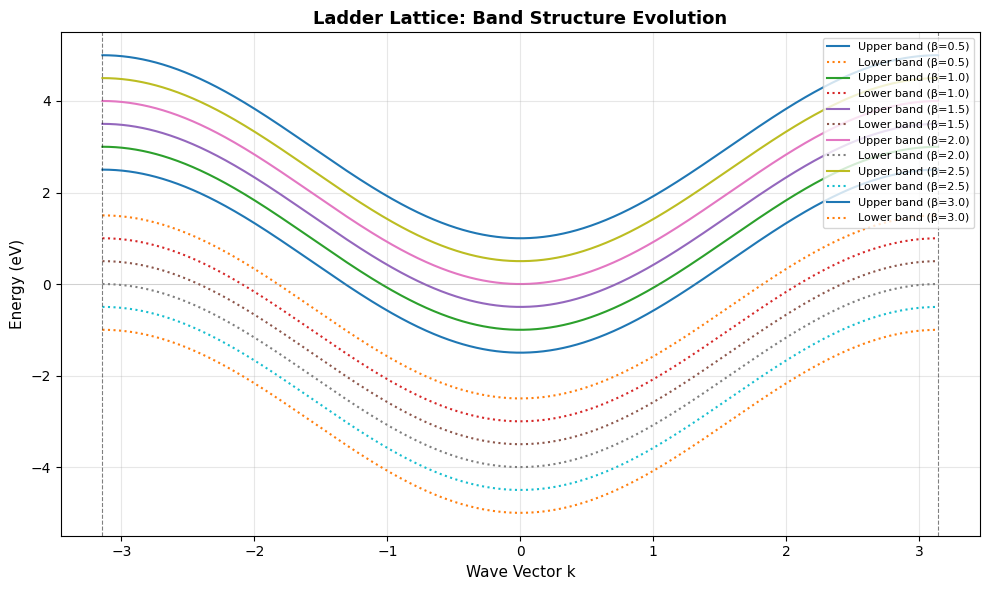


Transition occurs at β = 2α = 2.0


In [ ]:
# Q 1.2 : LADDER LATTICE 

# intra-chain hopping strength
alpha = 1.0 
# inter-chain hopping values  
beta_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]  
lattice_const = 1.0

# Create k-space sampling
k_samples = np.linspace(-np.pi/lattice_const, np.pi/lattice_const, 1000)

print("="*70)
print("PART 1: TWO-LEG LADDER LATTICE - Metal-Insulator Transition")
print("="*70)

fig, ax = plt.subplots(figsize=(10, 6))

for beta in beta_values:
## Calculate band energies
    band_upper = -2*alpha*np.cos(k_samples*lattice_const) + beta
    band_lower = -2*alpha*np.cos(k_samples*lattice_const) - beta
    
    # Determine band gap
    lower_band_max = np.max(band_lower)
    upper_band_min = np.min(band_upper)
    band_gap = upper_band_min - lower_band_max
    
    
    ### Classification
    if band_gap > 0.01:
        state = "Insulating"
    elif band_gap < -0.01:
        state = "Metallic"
    else:
        state = "Critical Point"
    
    print(f"β = {beta:.1f} | Band Gap = {band_gap:7.3f} eV | Phase: {state}")
    
    #Plot
    ax.plot(k_samples, band_upper, linewidth=1.5, label=f'Upper band (β={beta})')
    ax.plot(k_samples, band_lower, linewidth=1.5, linestyle=':', label=f'Lower band (β={beta})')

ax.axvline(-np.pi/lattice_const, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(np.pi/lattice_const, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_xlabel('Wave Vector k', fontsize=11)
ax.set_ylabel('Energy (eV)', fontsize=11)
ax.set_title('Ladder Lattice: Band Structure Evolution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nTransition occurs at β = 2α = {2*alpha}")

---

# Q.2: Diagonal Hopping effects

## Enhanced System with diagonal hopping

We now include diagonal hopping (denoted as γ) between opposite lattice sites:

$$H(k) = \begin{pmatrix}
-2\alpha \cos(ka) & -\beta - V(k) \\
-\beta - V(k) & -2\alpha \cos(ka)
\end{pmatrix}$$

where the diagonal element involves a k-dependent term.

### Case (a): Exponential Form
$$V(k) = \gamma e^{ika}$$

### Case (b): Cosine Form
$$V(k) = 2\gamma \cos(ka)$$

## Constraint
$$|\gamma| < \min(|\alpha|, |\beta|)$$



PART 2A: Diagonal Hopping Effects
Setup: α=2.0, β=4.0

γ =   0.00 | Gap =   0.000 eV | Phase: Critical
γ =   0.60 | Gap =   0.000 eV | Phase: Critical
γ =   0.30 | Gap =   0.000 eV | Phase: Critical
γ =  -0.30 | Gap =   0.000 eV | Phase: Critical
γ =  -0.60 | Gap =   0.000 eV | Phase: Critical


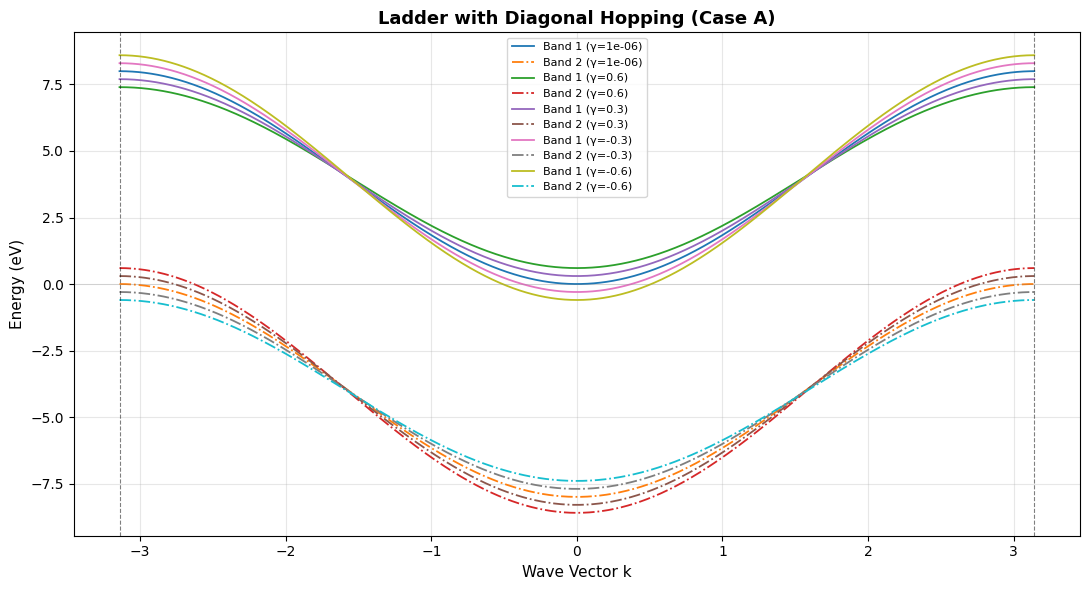


PART 2B: Diagonal Hopping Effects
Setup: α=2.0, β=4.0

γ =   0.00 | Gap =   0.000 eV | Phase: Critical
γ =   0.60 | Gap =   0.000 eV | Phase: Critical
γ =   0.30 | Gap =   0.000 eV | Phase: Critical
γ =  -0.30 | Gap =   0.000 eV | Phase: Critical
γ =  -0.60 | Gap =   0.000 eV | Phase: Critical


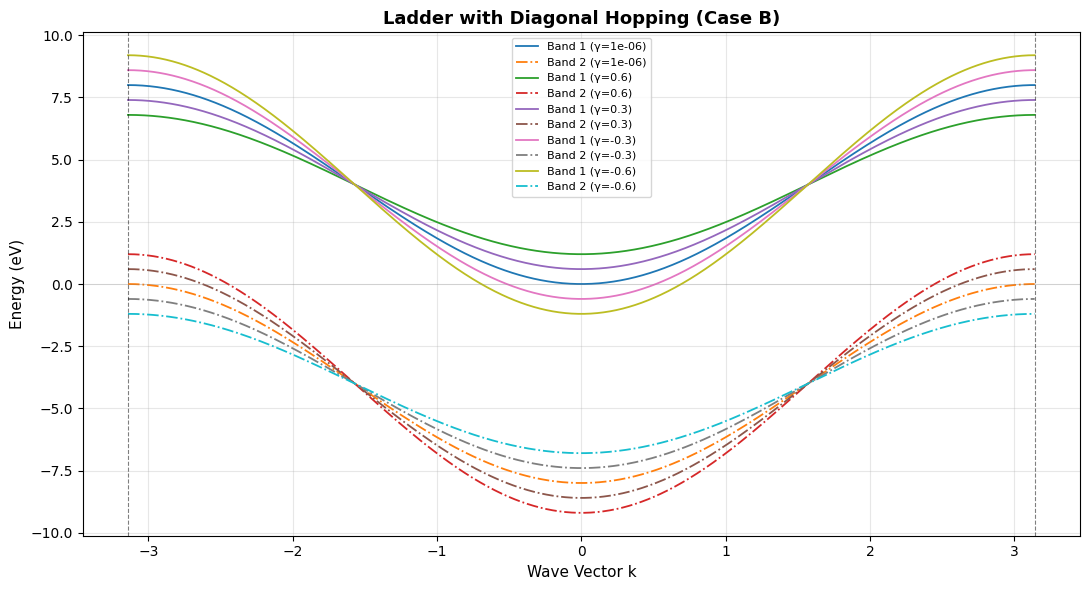

In [ ]:
# ###Q 2.2 : DIAGONAL HOPPING EFFECTS 

alpha_p2 = 2.0    # intra-chain hopping


beta_p2 = 4.0    ##inter-chain hopping

gamma_values = [1e-6, 0.6, 0.3, -0.3, -0.6]  #diagonal hopping values
lattice_const = 1.0

def analyze_ladder_with_diagonal(gamma_array, alpha, beta, lattice_const, geometry_type):
    """
    Analyze band structure of ladder lattice with diagonal hopping.
    
    Parameters:
    - gamma_array: array of diagonal hopping values
    - alpha: intra-chain hopping
    - beta: inter-chain hopping
    - lattice_const: lattice constant a
    - geometry_type: 'a' (exponential) or 'b' (cosine)
    """
    
    fig, ax = plt.subplots(figsize=(11, 6))
    k_array = np.linspace(-np.pi/lattice_const, np.pi/lattice_const, 1000)
    
    print(f"\n{'='*70}")
    print(f"PART 2{geometry_type.upper()}: Diagonal Hopping Effects")
    print(f"{'='*70}")
    print(f"Setup: α={alpha}, β={beta}\n")
    
    for gamma in gamma_array:
        energy_upper = []
        energy_lower = []
        
        for k in k_array:
            # Build Hamiltonian
            diag_elem = -2*alpha*np.cos(k*lattice_const)
            
            if geometry_type == 'a':
                # Exponential form
                off_diag = -beta - gamma*np.exp(1j*k*lattice_const)
            elif geometry_type == 'b':
                # Cosine form
                off_diag = -beta - 2*gamma*np.cos(k*lattice_const)
            else:
                raise ValueError("geometry_type must be 'a' or 'b'")
            
            H_matrix = np.array([
                [diag_elem, off_diag],
                [np.conj(off_diag), diag_elem]
            ], dtype=complex)
            
        # Diagonalize
            eigenvalues = np.linalg.eigvalsh(H_matrix)
            energy_lower.append(eigenvalues[0])
            energy_upper.append(eigenvalues[1])
        
        energy_upper = np.array(energy_upper)
        energy_lower = np.array(energy_lower)
        
        # Compute band gap
        gap_value = np.min(energy_upper) - np.max(energy_lower)
        
        ### Determine phase
        if gap_value > 0.01:
            phase_label = "Insulating"
        elif gap_value < -0.01:
            phase_label = "Metallic"
        else:
            phase_label = "Critical"
        
        print(f"γ = {gamma:6.2f} | Gap = {gap_value:7.3f} eV | Phase: {phase_label}")
        
        # plotS
        ax.plot(k_array, energy_upper, linewidth=1.3, label=f'Band 1 (γ={gamma})')
        ax.plot(k_array, energy_lower, linewidth=1.3, linestyle='-.', 
               label=f'Band 2 (γ={gamma})')
    
    ax.axvline(-np.pi/lattice_const, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(np.pi/lattice_const, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_xlabel('Wave Vector k', fontsize=11)
    ax.set_ylabel('Energy (eV)', fontsize=11)
    ax.set_title(f'Ladder with Diagonal Hopping (Case {geometry_type.upper()})', 
                fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

### Analyze both geometries
analyze_ladder_with_diagonal(gamma_values, alpha_p2, beta_p2, lattice_const, 'a')
analyze_ladder_with_diagonal(gamma_values, alpha_p2, beta_p2, lattice_const, 'b')

---

# Q3: 2D Square Lattice with nearest and next-nearest neighbor hopping

## System description

A two-dimensional square lattice with:
- **Nearest-neighbor (NN) hopping**: t_NN
- **Next-nearest-neighbor (NNN) hopping**: t_NNN (diagonal elements)

## Hamiltonian in Real Space

$$H = -t_{NN}\sum_{\langle i,j \rangle} c_i^\dagger c_j - t_{NNN}\sum_{\langle\langle i,j \rangle\rangle} c_i^\dagger c_j$$

## Dispersion relation

### (a) NN hopping only
$$E(k_x, k_y) = -2t_{NN}(\cos k_x + \cos k_y)$$

### (b) NN + NNN hhopping
$$E(k_x, k_y) = -2t_{NN}(\cos k_x + \cos k_y) - 4t_{NNN}\cos k_x \cos k_y$$

## Fermi surface analysis

For a given electron filling fraction f (electrons per unit cell), the Fermi energy E_F is determined by:

$$N(E_F) = f \times N_{\text{states}}$$

where the Fermi surface is the locus of points where E(k) = E_F.



PART 3A: 2D Square Lattice Band Structure & Fermi Surface
Parameters: t_NN = 2.0 eV

Filling = 0.50 e/cell → E_F =  -2.846 eV
Filling = 0.75 e/cell → E_F =  -1.090 eV
Filling = 1.00 e/cell → E_F =   0.031 eV
Filling = 1.25 e/cell → E_F =   1.181 eV
Filling = 1.50 e/cell → E_F =   2.933 eV
Filling = 1.75 e/cell → E_F =   5.210 eV
Filling = 2.00 e/cell → E_F =   8.000 eV


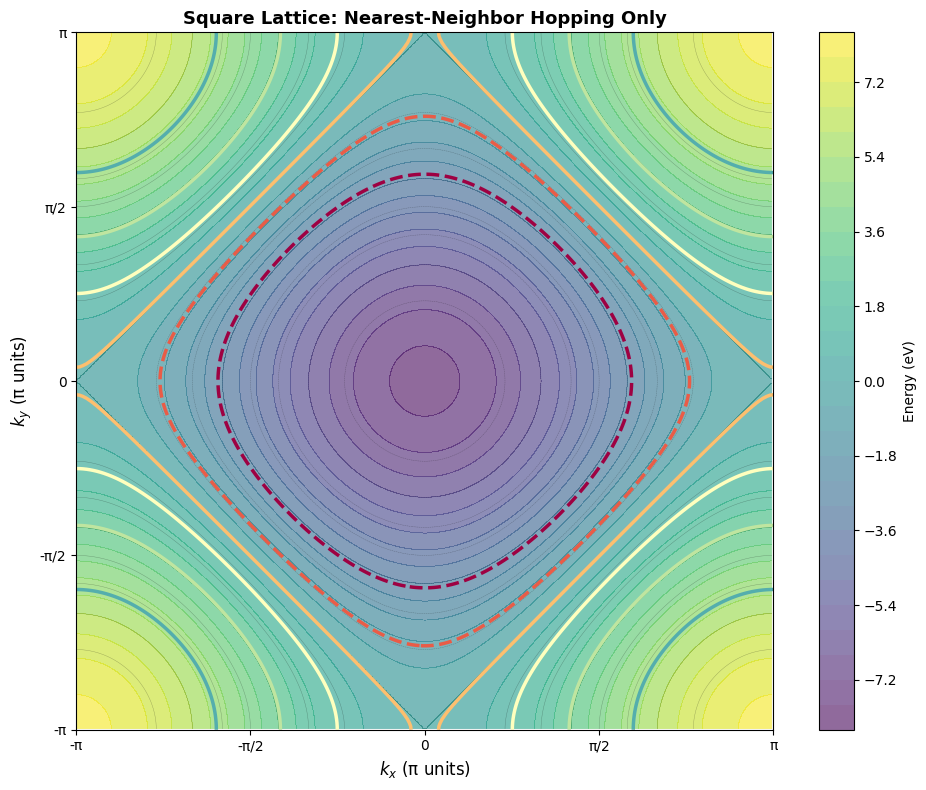


PART 3B: 2D Square Lattice Band Structure & Fermi Surface
Parameters: t_NN = 2.0 eV, t_NNN = -1.0 eV

Filling = 0.50 e/cell → E_F =  -3.669 eV
Filling = 0.75 e/cell → E_F =  -3.045 eV
Filling = 1.00 e/cell → E_F =  -1.902 eV
Filling = 1.25 e/cell → E_F =  -0.048 eV
Filling = 1.50 e/cell → E_F =   2.723 eV
Filling = 1.75 e/cell → E_F =   6.672 eV
Filling = 2.00 e/cell → E_F =  12.000 eV


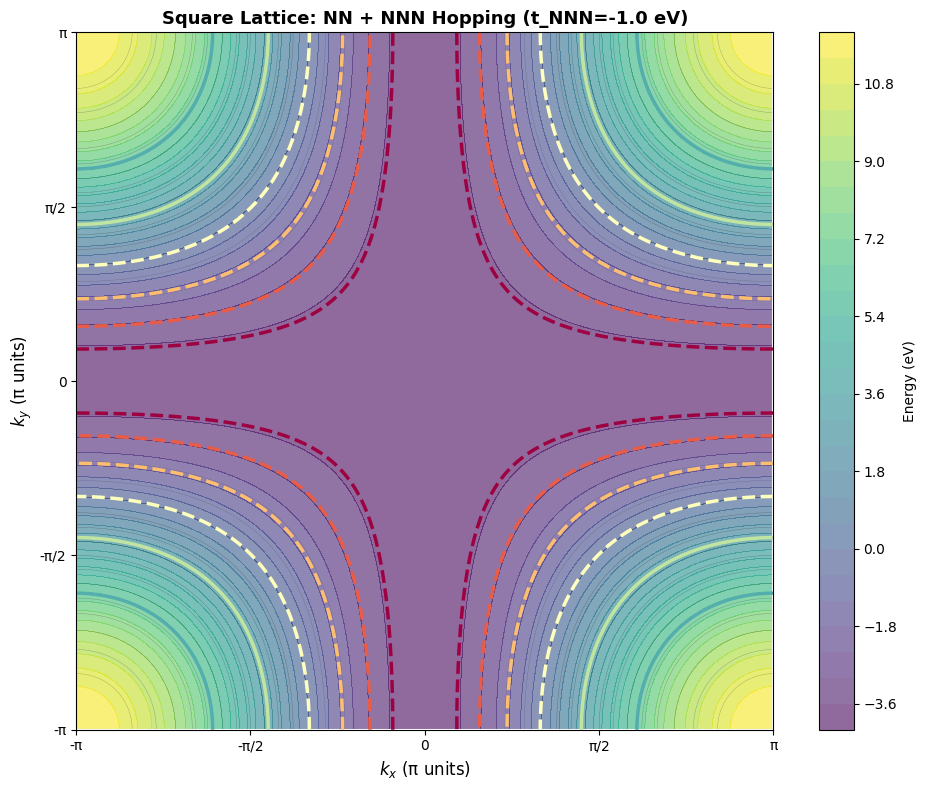


PART 3B: 2D Square Lattice Band Structure & Fermi Surface
Parameters: t_NN = 2.0 eV, t_NNN = 1.0 eV

Filling = 0.50 e/cell → E_F =  -2.574 eV
Filling = 0.75 e/cell → E_F =   0.166 eV
Filling = 1.00 e/cell → E_F =   1.988 eV
Filling = 1.25 e/cell → E_F =   3.102 eV
Filling = 1.50 e/cell → E_F =   3.700 eV
Filling = 1.75 e/cell → E_F =   3.953 eV
Filling = 2.00 e/cell → E_F =   4.000 eV


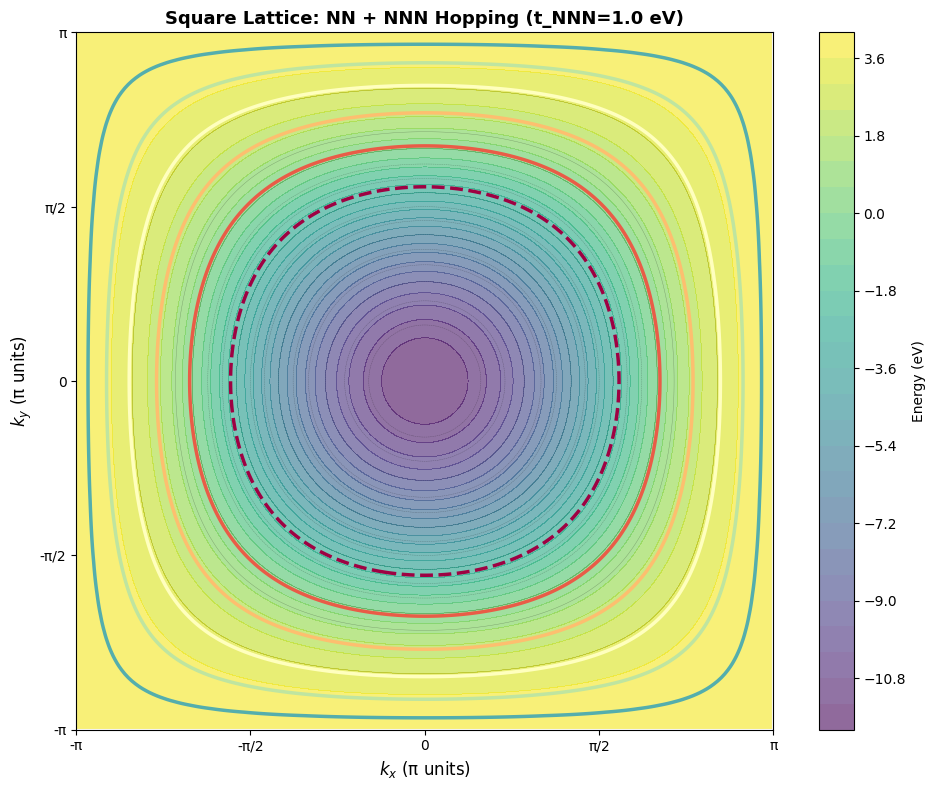

In [ ]:
###Q.3: SQUARE LATTICE 

t_nn = 2.0  #   nearest neighbor hopping in eV
t_nnn_values = [-1.0, 1.0]      # next-nearest neighbor values

def plot_square_lattice_structure(t_nn_val, t_nnn_val, case_label):
    """
    Plot band structure contour and Fermi surfaces for square lattice.
    """
    
    # Create k-space grid over first Brillouin zone
    kx_grid = np.linspace(-np.pi, np.pi, 200)
    ky_grid = np.linspace(-np.pi, np.pi, 200)
    KX, KY = np.meshgrid(kx_grid, ky_grid)
    
    # Calculate energy surface
    if case_label == 'a':
        E_surface = -2*t_nn_val*(np.cos(KX) + np.cos(KY))
        title_str = "Square Lattice: Nearest-Neighbor Hopping Only"
    elif case_label == 'b':
        E_surface = (-2*t_nn_val*(np.cos(KX) + np.cos(KY)) - 
                    4*t_nnn_val*np.cos(KX)*np.cos(KY))
        title_str = f"Square Lattice: NN + NNN Hopping (t_NNN={t_nnn_val} eV)"
    else:
        raise ValueError("case_label must be 'a' or 'b'")
    
    # Sort all energies to determine Fermi levels
    E_sorted = np.sort(E_surface.flatten())
    num_states = len(E_sorted)
    
    # Electron filling values
    filling_factors = np.arange(0.5, 2.01, 0.25)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Draw energy contours
    contour_map = ax.contourf(KX, KY, E_surface, levels=30, cmap='viridis', alpha=0.6)
    contour_lines = ax.contour(KX, KY, E_surface, levels=15, colors='k', 
                              linewidths=0.3, alpha=0.3)
    
    # Mark BZ boundaries
    ax.axhline(-np.pi, color='white', linestyle='-', linewidth=1.5)
    ax.axhline(np.pi, color='white', linestyle='-', linewidth=1.5)
    ax.axvline(-np.pi, color='white', linestyle='-', linewidth=1.5)
    ax.axvline(np.pi, color='white', linestyle='-', linewidth=1.5)
    
    print(f"\n{'='*70}")
    print(f"PART 3{case_label.upper()}: 2D Square Lattice Band Structure & Fermi Surface")
    print(f"{'='*70}")
    if case_label == 'b':
        print(f"Parameters: t_NN = {t_nn_val} eV, t_NNN = {t_nnn_val} eV\n")
    else:
        print(f"Parameters: t_NN = {t_nn_val} eV\n")
    
    # Plot Fermi surfaces
    colors_fs = plt.cm.Spectral(np.linspace(0, 1, len(filling_factors)))
    
    for idx, filling in enumerate(filling_factors):
        # Index in sorted energy array (2 states per unit cell)
        state_idx = int(filling/2.0 * (num_states - 1))
        fermi_energy = E_sorted[state_idx]
        
        # Draw Fermi contour
        cs = ax.contour(KX, KY, E_surface, levels=[fermi_energy], 
                       colors=[colors_fs[idx]], linewidths=2.5)
        
        print(f"Filling = {filling:.2f} e/cell → E_F = {fermi_energy:7.3f} eV")
    
    # Add colorbar
    cbar = plt.colorbar(contour_map, ax=ax, label='Energy (eV)')
    
    ax.set_xlabel('$k_x$ (π units)', fontsize=12)
    ax.set_ylabel('$k_y$ (π units)', fontsize=12)
    ax.set_title(title_str, fontsize=13, fontweight='bold')
    ax.set_aspect('equal')
    
    # Format tick labels
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    
    plt.tight_layout()
    plt.show()

# Case 3(a): NN hopping only
plot_square_lattice_structure(t_nn, None, 'a')

# Case 3(b): NN + NNN hopping
for t_nnn in t_nnn_values:
    plot_square_lattice_structure(t_nn, t_nnn, 'b')